In [11]:
# IMPORTS
import os
import sys
import igl # curvature computations
import itertools
import importlib
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, issparse
from scipy.sparse.csgraph import shortest_path
from collections import deque
from collections import defaultdict
from collections import Counter


sys.path.append('/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/')
import projectUtils as prjUtils
import stitchSurfs as stitch

import gen
import visUtils as vis

In [12]:
# visualization functions
import vtk
import gc

def get_vtk_faces(faces):
    # VTK faces format: [3, v0,v1,v2, 3, v0,v1,v2, ...]
    n_faces = faces.shape[0]
    vtk_faces = np.empty((n_faces * 4,), dtype=np.uint32)  # 3 verts + 1 count per triangle
    vtk_faces[0::4] = 3  # Triangle marker
    vtk_faces[1::4] = faces[:, 0]
    vtk_faces[2::4] = faces[:, 1]  
    vtk_faces[3::4] = faces[:, 2]

    return vtk_faces

def show_conComps(vertices, faces, component_id):
    vtk_faces = get_vtk_faces(faces)

    # Create PyVista mesh
    mesh = pv.PolyData(vertices, vtk_faces)  # PyVista expects [n,3] faces
    mesh.point_data['RegionId'] = component_id

    # Color by component (cyclic colormap)
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, scalars='RegionId', cmap='tab20', show_edges=False, edge_color='black')
    plotter.add_title(f'Connected Components')
    plotter.show()
    return mesh

def show_mesh(vertices, faces, title: str = None, vertices_highlight: None | list = None):
    vtk_faces = get_vtk_faces(faces)  # assume this exists

    # Create PyVista mesh
    mesh = pv.PolyData(vertices, vtk_faces)
    plotter = pv.Plotter()
    
    if vertices_highlight is not None:
        labels = np.zeros(len(vertices), dtype=int)
        if type(vertices_highlight[0]) in [list, set]:
            # Assign integer label to each vertex (0=background, 1+=group id)
            n_groups = len(vertices_highlight)
            for group_id, group_verts in enumerate(vertices_highlight, 1):
                # print(f"[group {group_id}] len {len(group_verts)}, type {type(group_verts)}: {group_verts}")
                labels[list(group_verts)] = group_id  # set label for vertices in this group
            
            mesh["highlight_groups"] = labels
            
            # Create discrete colormap: gray background + one color per group
            colors = ["lightgray"] + [f"C{i}" for i in range(n_groups)]
            plotter.add_mesh(mesh, scalars="highlight_groups", cmap=colors, 
                            show_edges=False, 
                            show_scalar_bar = False,
                            interpolate_before_map=False)
        else: # assumes list of verteex indices
            colors = np.zeros(len(vertices))
            colors[vertices_highlight] = 1   # mark special vertices
            mesh["highlight"] = colors
            plotter.add_mesh(mesh, scalars="highlight", 
                             cmap=["lightgray", "red"], 
                             show_edges=True,
                             show_scalar_bar = False)
    else:
        plotter.add_mesh(mesh, cmap='tab20', show_edges=True, edge_color='black')
    
    if title is not None:
        plotter.add_title(title)
        
    plotter.show()
    return mesh


def show_mesh_map(vertices, faces, values:np.array, title: str = None, cmap:str='RdBu'):
    vtk_faces = get_vtk_faces(faces)  # assume this exists

    # Compute 5th and 95th percentiles for clim
    vmin = np.percentile(values, 5)
    vmax = np.percentile(values, 95)

    # Create PyVista mesh
    mesh = pv.PolyData(vertices, vtk_faces)
    mesh.point_data['values'] = values  # For VERTEX coloring

    plotter = pv.Plotter()
    if title is not None:
        plotter.add_title(title)

    plotter.add_mesh(mesh, 
                     scalars='values', 
                     clim=[vmin, vmax],
                     cmap=cmap,
                     show_edges=False, 
                     edge_color='black',
                     line_width=0.5)
    
    plotter.show()
    return mesh

In [13]:
# computational functions

def countLabels(lbl_gii_pth, toPrint=False):
    lbl_gii = nib.load(lbl_gii_pth)
    lbl_data = lbl_gii.darrays[0].data
    unique, counts = np.unique(lbl_data, return_counts=True)
    if toPrint:
        for val, cnt in zip(unique, counts):
            print(f"\tLabel Value: {val} - Count: {cnt}")
    return dict(zip(unique, counts))

def graphCtxHippLbls(ctx_lbl:dict, hipp_lbl:dict, label_colName:str="LName"):
    out_ctx = countLabels(lbl_gii_pth = ctx_lbl['pth_label_gii'], toPrint=False)
    out_hipp = countLabels(lbl_gii_pth = hipp_lbl['pth_label_gii'], toPrint=False)

    # print human interpretable label
    ctx_csv = pd.read_csv(ctx_lbl['pth_lut'])
    hipp_csv = pd.read_csv(hipp_lbl['pth_lut'])

    # visualize as bar graphs
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # Plot cortex data
    labels_ctx = list(out_ctx.keys())
    counts_ctx = list(out_ctx.values())

    # Get human-readable labels for cortex
    ctx_csv = pd.read_csv(ctx_lbl['pth_lut'])
    ctx_labels_readable = []
    for label_val in labels_ctx:
        row = ctx_csv[ctx_csv['idx'] == label_val]
        if not row.empty:
            ctx_labels_readable.append(f"{str(int(label_val))}:{row[label_colName].iloc[0]}")
        else:
            ctx_labels_readable.append(f"{str(int(label_val))}:Unknown")

    ax1.bar(range(len(labels_ctx)), counts_ctx)
    ax1.set_title(f'Cortex Label Counts ({ctx_lbl["parcellationName"]})')
    ax1.set_xlabel('Label Value')
    ax1.set_ylabel('Count')
    ax1.set_xticks(range(len(labels_ctx)))
    ax1.set_xticklabels(ctx_labels_readable, rotation=90, fontsize=8)

    # Plot hippocampus data
    labels_hipp = list(out_hipp.keys())
    counts_hipp = list(out_hipp.values())

    # Get human-readable labels for hippocampus
    hipp_csv = pd.read_csv(hipp_lbl['pth_lut'])
    hipp_labels_readable = []
    for label_val in labels_hipp:
        row = hipp_csv[hipp_csv['idx'] == label_val]
        if not row.empty:
            hipp_labels_readable.append(f"{str(int(label_val))}:{row[label_colName].iloc[0]}")
        else:
            hipp_labels_readable.append(f"{str(int(label_val))}:Unknown")

    ax2.bar(range(len(labels_hipp)), counts_hipp)
    ax2.set_title(f'Hippocampus Label Counts ({hipp_lbl["parcellationName"]})')
    ax2.set_xlabel('Label Value')
    ax2.set_ylabel('Count')
    ax2.set_xticks(range(len(labels_hipp)))
    ax2.set_xticklabels(hipp_labels_readable, rotation=90, fontsize=8)

    all_labels = sorted(set(labels_ctx + labels_hipp))  # All unique labels
    counts_combined = []
    for label in all_labels:
        ctx_count = out_ctx.get(label, 0)
        hipp_count = out_hipp.get(label, 0)
        counts_combined.append(ctx_count + hipp_count)

    combined_labels_readable = []
    for i, label in enumerate(all_labels):
        if i < len(counts_combined):  # Match with filtered counts
            row_ctx = ctx_csv[ctx_csv['idx'] == label]
            row_hipp = hipp_csv[hipp_csv['idx'] == label]
            name = "Unknown"
            if not row_ctx.empty:
                name = row_ctx[label_colName].iloc[0]
            elif not row_hipp.empty:
                name = row_hipp[label_colName].iloc[0]
            combined_labels_readable.append(f"{str(int(label))}:{name}")

    ax3.bar(range(len(counts_combined)), counts_combined, color='lightgreen', alpha=0.8)
    ax3.set_title('Combined (Cortex + Hippocampus)')
    ax3.set_xlabel('Label Value')
    ax3.set_ylabel('Total Count')
    ax3.set_xticks(range(len(counts_combined)))
    ax3.set_xticklabels(combined_labels_readable, rotation=90, fontsize=8)

    # Set same scale for both plots
    max_count = max(max(counts_hipp), max(counts_ctx))*1.05
    ax1.set_ylim(0, max_count)
    ax2.set_ylim(0, max_count)

    plt.tight_layout()
    plt.show()

def graphStitchedLbls(stitch_lbl_pth: str, details_csv_pth: str):
    out_stitch = countLabels(lbl_gii_pth=stitch_lbl_pth, toPrint=False)

    stitch_csv = pd.read_csv(details_csv_pth)
    labels_readable = []
    for label_val in out_stitch:
        row = stitch_csv[stitch_csv['idx'] == label_val]
        if not row.empty:
            labels_readable.append(f"{str(int(label_val))}:{row['LName'].iloc[0]}")
        else:
            labels_readable.append(f"{str(int(label_val))}:Unknown")
            
    # visualize as bar graph
    plt.figure(figsize=(15, 8))
    labels_stitch = list(out_stitch.keys())
    counts_stitch = list(out_stitch.values())
    plt.bar(range(len(labels_stitch)), counts_stitch, color='coral')
    plt.title('Stitched Labels Counts')
    plt.xlabel('Label Value')
    plt.ylabel('Count')
    plt.xticks(range(len(labels_stitch)), labels_readable, rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()

def graphStitchMaskLbls(lbl_stitch_mask_pth, ctx_lbl:dict, hipp_lbl:dict, details_csv_pth, label_colName:str="LName", 
                        title:str=None):
    out_stitch_mask = countLabels(lbl_gii_pth=lbl_stitch_mask_pth, toPrint=False)
    out_ctx = countLabels(lbl_gii_pth = ctx_lbl['pth_label_gii'], toPrint=False)
    out_hipp = countLabels(lbl_gii_pth = hipp_lbl['pth_label_gii'], toPrint=False)

    # get human interpretable label
    labels_readable_stitchMask = get_lbls_readable(out_stitch_mask, details_csv_pth, label_colName)

    # visualize as bar graph with overlay comparison
    fig, (ax1) = plt.subplots(1, 1, figsize=(20, 8))
    
    # Right plot: Comparison overlay
    # Create mapping by LName for ctx and hipp
    stitch_csv = pd.read_csv(details_csv_pth)
    ctx_csv = pd.read_csv(ctx_lbl['pth_lut'])
    hipp_csv = pd.read_csv(hipp_lbl['pth_lut'])
    
    # Prepare data for overlay plot
    mask_counts = []
    ctx_counts = []
    hipp_counts = []
    label_names = []
    
    for label_val in out_stitch_mask:
        # Get LName from stitched CSV
        stitch_row = stitch_csv[stitch_csv['idx'] == label_val]
        if not stitch_row.empty:
            lname = stitch_row[label_colName].iloc[0]
            label_names.append(f"{int(label_val)}:{lname}")
            mask_counts.append(out_stitch_mask[label_val])
            
            # Find matching ctx count by LName
            ctx_match = ctx_csv[ctx_csv[label_colName] == lname]
            if not ctx_match.empty:
                ctx_idx = ctx_match['idx'].iloc[0]
                ctx_counts.append(out_ctx.get(ctx_idx, 0))
            else:
                ctx_counts.append(0)
            
            # Find matching hipp count by LName
            hipp_match = hipp_csv[hipp_csv[label_colName] == lname]
            if not hipp_match.empty:
                hipp_idx = hipp_match['idx'].iloc[0]
                hipp_counts.append(out_hipp.get(hipp_idx, 0))
            else:
                hipp_counts.append(0)
    
    x_pos = range(len(label_names))
    width = 0.25
    
    ax1.bar([x - width for x in x_pos], mask_counts, width, label='Masked Stitched', color='skyblue', alpha=0.8)
    ax1.bar(x_pos, ctx_counts, width, label='Unstitched cortex', color='orange', alpha=0.8)
    ax1.bar([x + width for x in x_pos], hipp_counts, width, label='Unstitched Hippocampus', color='green', alpha=0.8)
    
    if title is None:
        ax1.set_title(f'Label Count Comparison (by {label_colName})')
    else:
        ax1.set_title(title)
    ax1.set_xlabel('Label Value')
    ax1.set_ylabel('Count')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(label_names, rotation=90, fontsize=8)
    ax1.legend()
    
    plt.tight_layout()
    plt.show()

def get_lbls_readable(countLabels_out:dict, details_csv_pth:str, csv_colName:str="LName"):
    stitch_csv = pd.read_csv(details_csv_pth)
    labels_readable = []
    for label_val in countLabels_out:
        row = stitch_csv[stitch_csv['idx'] == label_val]
        if not row.empty:
            labels_readable.append(f"{str(int(label_val))}:{row[csv_colName].iloc[0]}")
        else:
            labels_readable.append(f"{str(int(label_val))}:Unknown")
    return labels_readable

def ensure_no_holes(mask_eroded:np.ndarray, mask_orig_data:np.ndarray, adj_list):
    """Intersect eroded mask and original mask. Fill in holes connected to the largest component in eroded mask."""
    
    def bfs_largest_component(start_mask, visited):
        queue = deque([start_mask])
        component = [start_mask]
        visited.extend(start_mask)
    
        while queue:
            v = queue.popleft()
            for nb in adj_list[v]:
                if nb not in visited and start_mask[nb]:
                    visited.add(nb)
                    queue.append(nb)
                    component.append(nb)
        return component
    
    # Find largest component IN ORIGINAL mask
    visited = set()
    components = []
    n_vertices = len(mask_orig_data)
    for v in range(n_vertices):
        if mask_orig_data[v] and v not in visited:
            comp = bfs_largest_component(mask_orig_data, visited.copy())
            components.append(comp)
    
    if components:
        largest_orig = max(components, key=len)
        largest_orig_set = set(largest_orig)
        
        # Keep eroded vertices ONLY if connected to original largest component
        mask_final = np.zeros(n_vertices, dtype=bool)
        for v in range(n_vertices):
            if mask_eroded[v] and v in largest_orig_set:
                mask_final[v] = True
    else:
        mask_final = mask_eroded
    
    return mask_final

def get_edges(faces):
    edges = []
    for face in faces:
        n = len(face)

        for i in range(n):
            v1 = face[i]
            v2 = face[(i+1) % n]

            edge = tuple(sorted((v1, v2)))
            edges += [edge]
    
    return edges

def get_boundary_edges(edges:set):
    # If edge only present once in the list then, it is involved only in a single face
    counts = Counter(edges)
    return [e for e in edges if counts[e] == 1]

def get_uniqueVertices_from_edges(edges:set):
    vertices = set()
    for edge in edges:
        v1, v2 = edge[0], edge[1]
        vertices.update([v1,v2])
    return vertices

def get_edgeFaces(edge_vertices:list, faces):
    """Faces composed of vertices which are all edge vertices"""
    edge_vertices = set(edge_vertices)
    edge_faces = []
    
    for face in faces:
        is_edge_face = True
        for vertex in face:
            if vertex not in edge_vertices:
                is_edge_face = False
                break
        if is_edge_face:
            edge_faces.append(face)
    return edge_faces

def build_adj_list(faces):
    # Build adjacency list
    adj = defaultdict(list)
    edge_set = set()
    for face in faces:
        for i in range(3):
            v1, v2 = face[i], face[(i+1)%3]
            e = tuple(sorted([v1, v2]))
            if e not in edge_set:
                adj[v1].append(v2)
                adj[v2].append(v1)
                edge_set.add(e)
    
    return adj

def get_neighbours(vertex_idx, radius, adj_list, exclude_self=True):
    """Get neighbouring vertices within a set number of edges (geodesic distance) from center vertex."""
    if radius < 1:
        return []
    
    visited = set()
    queue = deque([(vertex_idx, 0)])  # (vertex, distance)
    neighbours = []
    
    while queue:
        v, dist = queue.popleft()
        
        if v in visited:
            continue
        visited.add(v)

        if dist <= radius:
            if dist > 0 or not exclude_self:
                neighbours.append(v)
        else:
            continue

        for nb in adj_list[v]:
            if nb not in visited:
                queue.append((nb, dist + 1))
    return neighbours

def connected_components_mesh(vertices, faces):
    adj = build_adj_list(faces)
    
    visited = np.zeros(len(vertices), dtype=bool)
    component_id = np.full(len(vertices), -1)
    n_components = 0
    stack = []
    
    for start in range(len(vertices)):
        if not visited[start]:
            # DFS flood-fill
            stack.append(start)
            visited[start] = True
            component_id[start] = n_components
            while stack:
                v = stack.pop()
                for nei in adj[v]:
                    if not visited[nei]:
                        visited[nei] = True
                        component_id[nei] = n_components
                        stack.append(nei)
            n_components += 1
    componentSizes = np.bincount(component_id)
    largestBin = np.argmax(componentSizes)
    return component_id, largestBin, n_components  # Per-vertex labels and num components

def rm_low_valence_vrtx(vertices, faces, min_valence=3):
    """Remove vertices connected with <= min_valence edges"""
    vertices = vertices.copy()
    faces = faces.copy()

    valence = np.zeros(len(vertices))
    for face in faces:
        for v in face:
            valence[v] += 1
    to_remove = np.where(valence <= min_valence)[0]
    print(f"Removing {len(to_remove)} vertices connected with <= {min_valence} edges")

    # filter
    keep_mask = ~np.isin(np.arange(len(vertices)), to_remove)
    new_vertices = vertices[keep_mask]
    
    # Filter faces AND remap indices
    face_mask = np.isin(faces, to_remove).sum(axis=1) == 0  # No removed verts
    old_faces = faces[face_mask]
    
    # Remap vertex indices
    old_to_new = np.full(len(vertices), -1)
    old_to_new[keep_mask] = np.arange(len(new_vertices))
    new_faces = old_to_new[old_faces]
    
    vertices, faces = new_vertices, new_faces
    
    return vertices, faces

def fill_holes_with_mask(vertices_filt, faces_filt, mask_path):
    """
    Fill holes by keeping only vertices inside mask.surf.gii (NO PyVista)
    
    Args:
        vertices_filt: (N,3) filtered vertices
        faces_filt: (M,3) OR flattened faces  
        mask_path: path to mask.surf.gii
    
    Returns:
        vertices: (N',3) vertices inside mask
        faces: (M',3) faces inside mask
    """
    # Ensure faces are 2D (handles both cases)
    if faces_filt.ndim == 1:
        n_faces = len(faces_filt) // 3
        faces_filt = faces_filt.reshape(n_faces, 3)
    else:
        faces_filt = faces_filt.copy()
    
    # Load mask mesh
    mask_surf = nib.load(mask_path)
    mask_verts = mask_surf.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
    mask_faces_raw = mask_surf.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data
    
    # Fix mask faces if flattened
    if mask_faces_raw.ndim == 1:
        n_mask_faces = len(mask_faces_raw) // 3
        mask_faces = mask_faces_raw.reshape(n_mask_faces, 3).astype(int)
    else:
        mask_faces = mask_faces_raw.astype(int)
    
    print(f"Input: {len(vertices_filt)} verts, {len(faces_filt)} faces ({faces_filt.shape})")
    
    # Simple bounding box filter first (fast pre-filter)
    mask_bounds = np.array([mask_verts[mask_faces].min(axis=0).min(axis=0),
                           mask_verts[mask_faces].max(axis=0).max(axis=0)])
    bbox_mask = ((vertices_filt >= mask_bounds[0]) & 
                (vertices_filt <= mask_bounds[1])).all(axis=1)
    
    if not np.any(bbox_mask):
        print("No vertices in mask bounds!")
        return vertices_filt[:0], faces_filt[:0]
    
    # Ray-triangle intersection for bbox candidates only
    def point_in_triangle(point, tri_verts):
        """Barycentric coordinates test"""
        v0, v1, v2 = tri_verts
        v0c = point - v0
        v1c = v1 - v0
        v2c = v2 - v0
        
        dot00 = np.dot(v1c, v1c)
        dot01 = np.dot(v1c, v2c)
        dot02 = np.dot(v1c, v0c)
        dot11 = np.dot(v2c, v2c)
        dot12 = np.dot(v2c, v0c)
        
        denom = dot00 * dot11 - dot01 * dot01
        if abs(denom) < 1e-8:
            return False
        
        u = (dot11 * dot02 - dot01 * dot12) / denom
        v = (dot00 * dot12 - dot01 * dot02) / denom
        
        return (u >= 0) and (v >= 0) and (u + v <= 1)
    
    def point_in_mask(point):
        """Test if point projects inside any mask triangle (2D projection)"""
        # Project to XY plane (fast approximation)
        pt2d = point[:2]
        for face in mask_faces:
            tri2d = mask_verts[face, :2]
            if point_in_triangle(point, mask_verts[face]):
                return True
        return False
    
    # Test bbox candidates
    candidates = np.where(bbox_mask)[0]
    point_mask = np.zeros(len(vertices_filt), dtype=bool)
    for idx in candidates:
        point_mask[idx] = point_in_mask(vertices_filt[idx])
    
    # Filter vertices
    vertices = vertices_filt[point_mask]
    
    # Filter faces (all 3 vertices must be inside)
    face_mask = point_mask[faces_filt].all(axis=1)
    faces_old = faces_filt[face_mask]
    
    # Remap vertex indices
    used_old_indices = np.unique(faces_old)
    old_to_new = np.full(len(vertices_filt), -1, dtype=int)
    old_to_new[used_old_indices] = np.arange(len(used_old_indices))
    faces = old_to_new[faces_old]
    
    print(f"Kept {np.sum(point_mask)}/{len(vertices_filt)} vertices inside mask")
    print(f"Kept {len(faces)}/{len(faces_filt)} faces")
    
    return vertices, faces.astype(np.uint32)

def mask_vertices(vertices_to_remove:set, vertices, faces, mask_vertex_values=None, indices=None):
    """
    Given a list of vertices to remove, vertices, faces, and optionally, a boolean mask array,
    update the vertices, faces, and mask to no longer include the vertices in vertices to remove.
    """
    
    remove_idx = np.array(list(vertices_to_remove))
    
    keep_mask = np.ones(len(vertices), dtype=bool)
    keep_mask[remove_idx] = False
    
    # Remove vertices
    vertices_filt = vertices[keep_mask]

    # Update faces
    old_to_new = np.full(len(vertices), -1, dtype=int)
    old_to_new[keep_mask] = np.arange(keep_mask.sum())

    # Filter faces: keep only those for whom all connected vertices remain
    faces_mask = np.all(np.isin(faces, np.where(keep_mask)[0]), axis=1)
    faces_filt = faces[faces_mask]
    faces_filt = old_to_new[faces_filt] # remap face indices
    
    # Apply changes to mask
    if mask_vertex_values is not None:
        mask_vertex_values = np.asarray(mask_vertex_values)
        mask_filt = mask_vertex_values[keep_mask]
    else:
        mask_filt = None
    
    if indices is not None:
        indices_filt = indices[keep_mask]
    else:
        indices_filt = None
        
    return vertices_filt, faces_filt, mask_filt, indices_filt

def get_setOfContinuousEdges(boundary_edges):
    # count number of edges until returning to the same edge
    # return list of counts where length of list is length of continous borders
    edges = [tuple(sorted(e)) for e in boundary_edges]
    adj = defaultdict(list) # list of all boundary vertices connected to any other boundary vertex
    for e in  edges:
        u, v = e
        adj[u].append(e)
        adj[v].append(e)
    
    unused = set(edges)
    loops = []

    for e0 in list(unused):
        if e0 not in unused:
            continue
        loop = []

        start_u, start_v = e0
        current_vertex = start_v
        start_vertex = start_u
        prev_edge = None

        unused.remove(e0)
        loop.append(e0)

        while True:
            candidates = [e for e in adj[current_vertex] if e in unused]
            if not candidates:
                break
            e_next = candidates[0]
            unused.remove(e_next)
            loop.append(e_next)
            u, v = e_next
            current_vertex = v if current_vertex == u else u

            if current_vertex == start_vertex:
                break
        
        loops.append(loop)
    loops.sort(key=len, reverse=True)
    
    return loops

def filt_loops(loops:list[set], min_numVrtx:int | None =None, max_numVrtx:int | None =None):
    if not loops:
        return []
    largest_loop = max(loops, key=len)
    loops_filt = []
    for loop in loops:
        if loop == largest_loop: # Exclude main boundary
           continue
        elif (min_numVrtx and max_numVrtx) and (min_numVrtx <= len(loop) <= max_numVrtx):
            loops_filt.append(loop)
        elif min_numVrtx and min_numVrtx <= len(loop):
            loops_filt.append(loop)
        elif max_numVrtx and len(loop) <= max_numVrtx:
            loops_filt.append(loop)
        else:
            loops_filt.append(loop)
    return loops_filt

def fill_holes(mask_clean:np.ndarray, filt_loops:list[set[int]], pth_inputSurf_gii:str) -> np.ndarray:
    """
    Fill multiple holes
    """
    if not filt_loops:
        print(f"[fill_holes] No holes to fill")
        return mask_clean.copy()

    surf_gii = nib.load(pth_inputSurf_gii)
    faces = surf_gii.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data.astype(int)
    adj_list = build_adj_list(faces)
    mask_filled = mask_clean.copy().astype(int)
    total_filled = 0

    sorted_loops = sorted(filt_loops, key=len, reverse = True)
    for i, hole_loop in enumerate(sorted_loops):
        hole_size = len(hole_loop)
        print(f"\n\tFilling hole {i+1}/{len(sorted_loops)} (perimeter {hole_size} vrtx)")

        mask_filled = flood_fill_single_hole(mask_filled, hole_loop, adj_list)
        total_filled += np.sum(mask_filled) - np.sum(mask_clean)
    
    print(f"\nTotal vertices added across all holes: {total_filled}")
    return mask_filled

def flood_fill_single_hole(mask_filled: np.ndarray, hole_loop:set[int], adj_list:list, max_iter = 20) -> np.ndarray:

    queue = deque(hole_loop)
    visited = set(hole_loop)

    for v in hole_loop:
        for neighbor in adj_list[v]:
            if neighbor not in visited and mask_filled[neighbor] == 0:
                queue.append(neighbor)
                visited.add(neighbor)
    
    if not queue:
        print(f"\tNo unmasked interior found")
        return mask_filled, 0
    
    print(f"\tStarting with {len(queue)} unmasked interior vertices")
    
    filled_count = 0
    for i in range(max_iter):
        current_layer_size = len(queue)
        if current_layer_size == 0:
            break
            
        for _ in range(current_layer_size):
            v = queue.popleft()
            if mask_filled[v] == 0:  # Still unmasked
                mask_filled[v] = 1
                filled_count += 1
                
                # Add more unmasked neighbors
                for neighbor in adj_list[v]:
                    if neighbor not in visited and mask_filled[neighbor] == 0:
                        queue.append(neighbor)
                        visited.add(neighbor)
        
        print(f"\tIter {i + 1}: +{current_layer_size} vertices processed")
    
    print(f"\tTotal filled: {filled_count}")
    return mask_filled

def get_holes_from_mask(mask_clean: np.ndarray, pth_inputSurf_gii: str, 
                       filter_minVrtx: int | None = None, filter_maxVrtx: int | None = None):
    """
    Find holes by looking at boundary edges of CURRENTLY MASKED vertices only.
    Returns loops in original surface index space (matches mask_clean).
    """
    # Load original surface
    surf_gii = nib.load(pth_inputSurf_gii)
    faces = surf_gii.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data.astype(int)
    
    # Build edges ONLY from masked faces (vertices where mask_clean==1)
    masked_faces = []
    for face in faces:
        if np.all(mask_clean[face] == 1):  # All 3 vertices masked
            masked_faces.append(face)
    
    #print(f"Masked surface: {len(masked_faces)} faces from {np.sum(mask_clean)} vertices")
    
    # Find boundary edges in masked surface only
    all_edges = get_edges(np.array(masked_faces))
    boundary_edges = get_boundary_edges(all_edges)
    loops = get_setOfContinuousEdges(boundary_edges)
    
    # Extract vertex sets from edge loops
    loop_vertices = []
    for loop in loops:
        loop_vrtx = set()
        for u, v in loop:
            loop_vrtx.add(u)
            loop_vrtx.add(v)
        loop_vertices.append(loop_vrtx)
    
    # Filter by size
    loops_filt = filt_loops(loop_vertices, filter_minVrtx, filter_maxVrtx)
    #print(f"{len(loops_filt)} hole loops found (min {filter_minVrtx}, max {filter_maxVrtx} verts)")
    
    return loops_filt

def map_original_to_masked(hole_loops: list[set[int]], mapping: dict, masked_indices: np.ndarray) -> list[set[int]]:
    """
    Map original surface indices → current masked mesh indices using mask_vertices logic.
    
    Uses the same old_to_new mapping pattern from your mask_vertices function.
    """
    keep_vertices = mapping['keep_vertices']  # original indices kept in masked mesh (length m)
    final_masked_indices = masked_indices     # final surviving masked indices (length k)
    
    # Create reverse mapping: masked_idx → current_idx (0..k-1)  
    # Same logic as old_to_new in mask_vertices
    masked_to_current = np.full(len(keep_vertices), -1, dtype=int)
    masked_to_current[final_masked_indices] = np.arange(len(final_masked_indices))
    
    # Map each hole loop
    highlighted_current = []
    for hole_loop in hole_loops:
        # Find hole vertices that survived to final mesh
        surviving_hole = []
        for orig_idx in hole_loop:
            # orig_idx → masked_idx using keep_vertices inverse lookup
            masked_idx = np.where(keep_vertices == orig_idx)[0]
            if len(masked_idx) > 0:  # Found in masked mesh
                masked_idx = masked_idx[0]
                current_idx = masked_to_current[masked_idx]
                if current_idx != -1:  # Survived to final mesh
                    surviving_hole.append(current_idx)
        
        if surviving_hole:
            highlighted_current.append(set(surviving_hole))
    
    return highlighted_current

def do_erode_dilate(mask_filled: np.ndarray, pth_surf_gii: str, n_erode: int = 1, n_dilate: int = 1) -> np.ndarray:
    print(f"{'-'*10}\nERODE (by {n_erode}) & DILATE (by {n_dilate})")
    
    surf_gii = nib.load(pth_surf_gii)
    faces = surf_gii.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data.astype(int)
    
    n_vertices = len(mask_filled)
    adj_list = build_adj_list(faces)
    
    mask_data = mask_filled.astype(bool)
    
    # ERODE: Remove thin protrusions
    mask_eroded = np.full(n_vertices, False, dtype=bool)
    for v in range(n_vertices):
        if mask_data[v]:
            neighbours = get_neighbours(v, n_erode, adj_list, exclude_self=True)
            if all(mask_data[nb] for nb in neighbours):
                mask_eroded[v] = True

    # DILATE: Smooth boundary
    mask_final = mask_eroded.copy()
    for v in range(n_vertices):
        if not mask_eroded[v]:
            neighbours = get_neighbours(v, n_dilate, adj_list, exclude_self=True)
            if any(mask_eroded[nb] for nb in neighbours):
                mask_final[v] = True
    
    print(f"Boundary smooth: {np.sum(mask_data)} → {np.sum(mask_final)} vertices")
    return mask_final.astype(int)

def rm_edgeFaces(faces, vertices, mask_curr, masked_indices, clean_params, noVrtxtoRemove=False):
    ## i. get boundary edges
    all_edges = get_edges(faces)
    boundary_edges = get_boundary_edges(all_edges)
    boundary_vertices = get_uniqueVertices_from_edges(boundary_edges)
    #print(f"{len(edges)} edges\n{len(boundary_edges)} boundary edges\n{len(edge_vertices)} edge vertices")
    if clean_params.get('show', True):
        #_ = show_mesh(vertices_in, faces, title = "Edge vertices", vertices_highlight = list(edge_vertices))
        pass

    ## ii. get faces entirely composed of edge verticess
    edge_faces = get_edgeFaces(boundary_vertices, faces)
    vertices_in_edge_faces = set()
    for edge_face in edge_faces:
        vertices_in_edge_faces.update(edge_face)
    
    ## iii. mask out relevant vertex
    if len(vertices_in_edge_faces) != 0:
        if clean_params.get('show', True):
            _ = show_mesh(vertices, faces,  
                    title = f"{len(vertices_in_edge_faces)} faces composed entirely of edge vertices", 
                    vertices_highlight=list(vertices_in_edge_faces))

        vertices_tmp, faces_tmp, mask_tmp, masked_indices_tmp  = mask_vertices(
                                                vertices_to_remove=vertices_in_edge_faces,
                                                vertices=vertices,
                                                faces=faces,
                                                mask_vertex_values=mask_curr,
                                                indices=masked_indices
                                            )
        if clean_params.get('show', True):
            #_ = show_mesh(vertices_tmp, faces_tmp, title = "Removed edge faces")
            pass
    else:
        noVrtxtoRemove = True
        print("No faces composed entirely of edge vertices.")
        vertices_tmp, faces_tmp, mask_tmp, masked_indices_tmp = vertices, faces, mask_curr, masked_indices
    
    return vertices_tmp, faces_tmp, mask_tmp, masked_indices_tmp, noVrtxtoRemove

def keep_largest_component(vertices, faces, mask, masked_indices, clean_params, noCompsToRemove=False):
    ## i. Determine largest component
    component_ids, largestBin, n_components = connected_components_mesh(vertices, faces)
    
    ## ii. Mask
    if n_components > 1:
        if clean_params.get('show', True):
            #mesh = show_conComps(vertices_tmp, faces_tmp, component_ids) # visualize
            pass
        
        vertices_notIn_bigBin = np.where(component_ids != largestBin)[0]
        vertices_out, faces_out, mask_curr, masked_indices_out = mask_vertices(
                                                vertices_to_remove=vertices_notIn_bigBin,
                                                vertices=vertices,
                                                faces=faces,
                                                mask_vertex_values=mask,
                                                indices=masked_indices
                                            )
        if clean_params.get('show', True):
            _ = show_mesh(vertices_out, faces_out, title = "Largest component")
    else:
        noCompsToRemove = True
        vertices_out, faces_out, mask_curr, masked_indices_out = vertices, faces, mask, masked_indices
        print(f"Only one component identified.")
    
    return vertices_out, faces_out, mask_curr, masked_indices_out, noCompsToRemove

def topology_cleaning(vertices_in, faces_in, mask_curr, clean_params:dict, raw_mask:dict, mapping):
    print(f"TOPOLOGY CLEANING\n\t-> Remove faces made only of edge vertices\n\t-> Retain largest component only")
    
    masked_indices = np.arange(mapping['n_masked'])
    for i in range(clean_params['iterations']):
        if i > 0:
            vertices_in = vertices_out
            faces_in = faces_out
            masked_indices = masked_indices_out

        print(f"{'-'*10} iteration {i+1}/{clean_params['iterations']} {'-'*10}")
        
        # 1. Mask out vertices causing faces made entirely of edge vertices
        vertices_tmp, faces_tmp, mask_tmp, masked_indices_tmp, noVrtxtoRemove = rm_edgeFaces(
            faces=faces_in, 
            vertices=vertices_in,
            mask_curr=mask_curr,
            masked_indices=masked_indices,
            clean_params=clean_params
            )
        
        # 2. Keep largest connected component
        vertices_out, faces_out, mask_curr, masked_indices_out, noCompsToRemove = keep_largest_component(
            vertices=vertices_tmp, 
            faces=faces_tmp,
            mask=mask_tmp,
            masked_indices=masked_indices_tmp,
            clean_params=clean_params, noCompsToRemove=False
            )

        print(f"{len(vertices_in)} -> {len(vertices_out)} vertices\n{len(faces_in)} -> {len(faces_out)} faces")

        if noVrtxtoRemove and noCompsToRemove:
            print(f"Not continuing to next iterations.")
            break

    # apply changes to raw_mask
    orig_idx_final = mapping['keep_vertices'][masked_indices_out]

    mask_clean = np.zeros_like(raw_mask['data'], dtype=int)
    mask_clean[orig_idx_final] = 1

    print(f"[TOPOLOGY CLEAN] Number of vertices: {len(vertices_in)} -> {np.sum(mask_clean == 1)}")

    return vertices_out, faces_out, mask_clean, masked_indices_out

def hole_filling(vertices, faces, mask, masked_indices, mapping, example_participant, show=True):
    print(f"{'-'*10}\nFILL HOLES")
    
    ## i. Identify & visualize
    vrtx_loops = get_holes_from_mask(mask_clean = mask, 
                        pth_inputSurf_gii = os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii"))
    
    vrtx_loops_current = map_original_to_masked(vrtx_loops, mapping, masked_indices)
    if show:
        _ = show_mesh(vertices, faces, title = f"Attempting to fill {len(vrtx_loops_current)} holes", 
                    vertices_highlight=vrtx_loops_current)

    ## ii. Fill
    mask_filled = fill_holes(mask_clean = mask, filt_loops = vrtx_loops, 
                            pth_inputSurf_gii=os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii"))
    
    return mask_filled

def clean_mask(raw_mask:dict, clean_params:dict, example_participant:dict):
    
    # Visualize input mask applied to example case
    pt_surf_masked_pth, mapping = prjUtils.apply_mask_to_stitchedGii(pth_inputSurf_gii=os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii"), 
                    pth_mask=raw_mask['pth'],
                    pth_out=os.path.join(example_participant['pt_out_root'], 
                    f"{example_participant['commonName']}_mask-mTemp-ctx-{clean_params['ctx_lbl']['parcName']}_hipp-{clean_params['hipp_lbl']['parcName']}_{clean_params['date']}.surf.gii"))

    masked_indices = np.arange(mapping['n_masked']) # indices of the vertices retained in mask
    keep_vertices = mapping['keep_vertices'] # shape (m,)
    mask_on_masked = raw_mask['data'][keep_vertices] # length m

    surf_mask = nib.load(pt_surf_masked_pth)
    orig_vertices = surf_mask.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
    orig_faces = surf_mask.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data
    print(f"Input vertices: {len(orig_vertices)} (faces: {len(orig_faces)})")

    if clean_params.get('show_initial', True):
        vis.visSurf(pt_surf_masked_pth, title = f"{example_participant['sub']}-{example_participant['ses']} raw masked surface")
    
    vertices_out, faces_out, mask_clean, masked_indices_out = topology_cleaning(vertices_in=orig_vertices, 
                                                            faces_in=orig_faces, 
                                                            mask_curr=mask_on_masked, 
                                                            clean_params=clean_params, 
                                                            raw_mask=raw_mask, 
                                                            mapping=mapping)

    mask_filled = hole_filling(vertices=vertices_out, 
                                faces=faces_out,
                                mask=mask_clean,
                                masked_indices = masked_indices_out,
                                mapping = mapping,
                                example_participant=example_participant,
                                show = clean_params.get('show', True))

    mask_final = do_erode_dilate(mask_filled, 
                                os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii"),
                                clean_params['n_erode'],
                                clean_params['n_dilate'])
    
    ## SAVE
    mask_final_gii = nib.GiftiImage()
    mask_final_gii.add_gifti_data_array(
        nib.gifti.GiftiDataArray(mask_final.astype(np.int32),
                                intent='NIFTI_INTENT_LABEL')
                    )
    mask_clean_save_pth = os.path.join(clean_params['tmplt_path_root'],
                                       f"{example_participant['commonName_anonymous']}_mask-mTempClean.label.gii")
    
    nib.save(mask_final_gii, mask_clean_save_pth)
    print(f"Saved cleaned mask: {mask_clean_save_pth}")

    # visualize output
    if clean_params.get('show_final', True):
        pt_surf_masked_pth, mapping = prjUtils.apply_mask_to_stitchedGii(pth_inputSurf_gii=os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii"), 
                        pth_mask=mask_clean_save_pth,
                    pth_out=os.path.join(example_participant['pt_out_root'], f"{example_participant['commonName']}_mask-mTempClean-ctx-{clean_params['ctx_lbl']['parcName']}_hipp-{clean_params['hipp_lbl']['parcName']}_{clean_params['date']}.surf.gii"))

        surf_final = nib.load(pt_surf_masked_pth)
        vrtx_final = surf_final.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
        faces_final = surf_final.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data

        all_edges = get_edges(np.array(faces_final))
        boundary_edges = get_boundary_edges(all_edges)
        loops = get_setOfContinuousEdges(boundary_edges)
        loops_filt = filt_loops(loops)
        print(f"{len(vrtx_final)} vertices in final mesh")
        _ = show_mesh(vrtx_final, faces_final, title = f"Final (remaining {len(loops_filt)} holes highlighted)", 
                    vertices_highlight=loops_filt)
    else:
        print("NOT VISUALIZING FINAL")

    return mask_clean_save_pth


# Follow curvature lines


In [14]:
# PARAMS

glsr_lbl = {
    "parcellationName": "Glasser360",
    "parcName": "glsr",
    "type": "label",

    "pth_label_gii":"/host/verges/tank/data/daniel/parcellations/glasser/glasser-360_conte69_rh.label.gii",
    "pth_lut": "/host/verges/tank/data/daniel/parcellations/glasser/glasser_idx-lbls.csv",
    "lut_idx_label_colNames": ["idx", "LName"],
}

aparc_lbl = {
    "parcellationName": "Desikan",
    "parcName": "DK",
    "type": "label",
    "pth_label_gii":"/host/verges/tank/data/daniel/parcellations/aparc/aparc-aseg_conte69_rh.label.gii",
    "pth_lut": "/host/verges/tank/data/daniel/parcellations/aparc/lut_aparc_DM.csv",
    "lut_idx_label_colNames": ["idx", "LName"],
}

aparc_a2009s_lbl = {
    "parcellationName": "aparc_a2009s",
    "parcName": "Destrieux",
    "type": "label",
    "pth_label_gii":"/host/verges/tank/data/daniel/parcellations/aparc_a2009s/aparc-a2009s_conte69_rh.label.gii",
    "pth_lut": "/host/verges/tank/data/daniel/parcellations/aparc_a2009s/lut_aparc-a2009s_DM.csv",
    "lut_idx_label_colNames": ["idx", "label"],
}

dk25_lbl = {
    "parcellationName": "DeKraker25",
    "parcName": "DK25",
    "type": "label",
    "pth_label_gii": "/host/verges/tank/data/daniel/parcellations/DeKraker25/sub-bigbrain_hemi-R_label-hipp_den-0p5mm_DeKraker25.label.gii",
    "pth_lut": "/host/verges/tank/data/daniel/parcellations/DeKraker25/DK25_details.csv",
    "lut_idx_label_colNames": ["idx", "LName"],
}

clean_params = {
    'date': "13Mar2026",
    'show': False,
    'show_initial': True,
    'show_final': True,
    'ctx_lbl': aparc_a2009s_lbl,
    'hipp_lbl': dk25_lbl,
    'iterations': 4,
    'n_erode':5,
    'n_dilate':3,
    'tmplt_path_root': "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/"
}

# test participant for visualization
example_participant = {
    'sub': "PNC018",
    'ses': 'a1',
    'hemi': 'L',
    'surf_date': '12Feb2026-1304',
    'pt_root': "/host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC018_ses-a1/surfs/",
    'pt_out_root': "/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-PNC018_ses-a1/surfs/",
    'commonName': f"sub-PNC018_ses-a1_hemi-L_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_12Feb2026-1304"
}

example_participant['commonName_anonymous'] = example_participant['commonName'].replace(f"sub-{example_participant['sub']}_ses-{example_participant['ses']}_hemi-{example_participant['hemi']}_", "").replace(example_participant['surf_date'], clean_params['date'])
example_surf_pth = os.path.join(example_participant['pt_root'], f"{example_participant['commonName']}.surf.gii")



1. STITCH LABELS...
No overlapping label values found between cortical and hippocampal labels.
	Saved merged look up table (6KB): /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lut_stitch_ctx-Destrieux_hipp-DK25_13Mar2026.csv
	Saved Gifti with updated label values (10KB): /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/labels_stitch_ctx-Destrieux_hipp-DK25_13Mar2026.label.gii

2. MAKE VERTEX MASK...
	Look up table column 'mesialTemporalMask' - Label values [1] found in rows: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2021, 2022, 2023, 2042, 2051, 2052, 2062]
	37741 (vertices in mask object) -> 9914 (vertices with mask = 1)
	Binary mask saved to: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/mask-mTemp_stitch_ctx-Destrieux_hipp-DK25_13Mar2026.label.gii

3. CLEAN VERTEX MASK...
	[apply_mask] Vertices: 37741 → 9914
	Saved [245KB]: /host/verges/tank/data/daniel/04_inVivoHistology/data/test/

Widget(value='<iframe src="http://localhost:40025/index.html?ui=P_0x7fac614d3610_0&reconnect=auto" class="pyvi…

TOPOLOGY CLEANING
	-> Remove faces made only of edge vertices
	-> Retain largest component only
---------- iteration 1/4 ----------
9914 -> 9284 vertices
19087 -> 18190 faces
---------- iteration 2/4 ----------
Only one component identified.
9284 -> 9251 vertices
18190 -> 18132 faces
---------- iteration 3/4 ----------
Only one component identified.
9251 -> 9239 vertices
18132 -> 18112 faces
---------- iteration 4/4 ----------
No faces composed entirely of edge vertices.
Only one component identified.
9239 -> 9239 vertices
18112 -> 18112 faces
Not continuing to next iterations.
[TOPOLOGY CLEAN] Number of vertices: 9239 -> 9239
----------
FILL HOLES

	Filling hole 1/9 (perimeter 13 vrtx)
	Starting with 13 unmasked interior vertices
	Iter 1: +13 vertices processed
	Total filled: 0

	Filling hole 2/9 (perimeter 7 vrtx)
	Starting with 7 unmasked interior vertices
	Iter 1: +7 vertices processed
	Total filled: 0

	Filling hole 3/9 (perimeter 6 vrtx)
	Starting with 7 unmasked interior vertice

Widget(value='<iframe src="http://localhost:40025/index.html?ui=P_0x7fac61d97310_1&reconnect=auto" class="pyvi…


----------------------------------------
FINAL MASK SAVED TO: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026_mask-mTempClean.label.gii

4. MASK THE LABEL FILE...
Retrieving label data from original mask
	[apply_mask] Vertices: 37741 → 9914
	Saved [23KB]: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/labels_stitch_ctx-Destrieux_hipp-DK25_13Mar2026_mask-mTemp.label.gii
Retrieving label data from cleaned mask
	[apply_mask] Vertices: 37741 → 8853
	Saved [20KB]: /host/verges/tank/data/daniel/04_inVivoHistology/code/resources/labels_stitch_ctx-Destrieux_hipp-DK25_13Mar2026_mask-mTempClean.label.gii


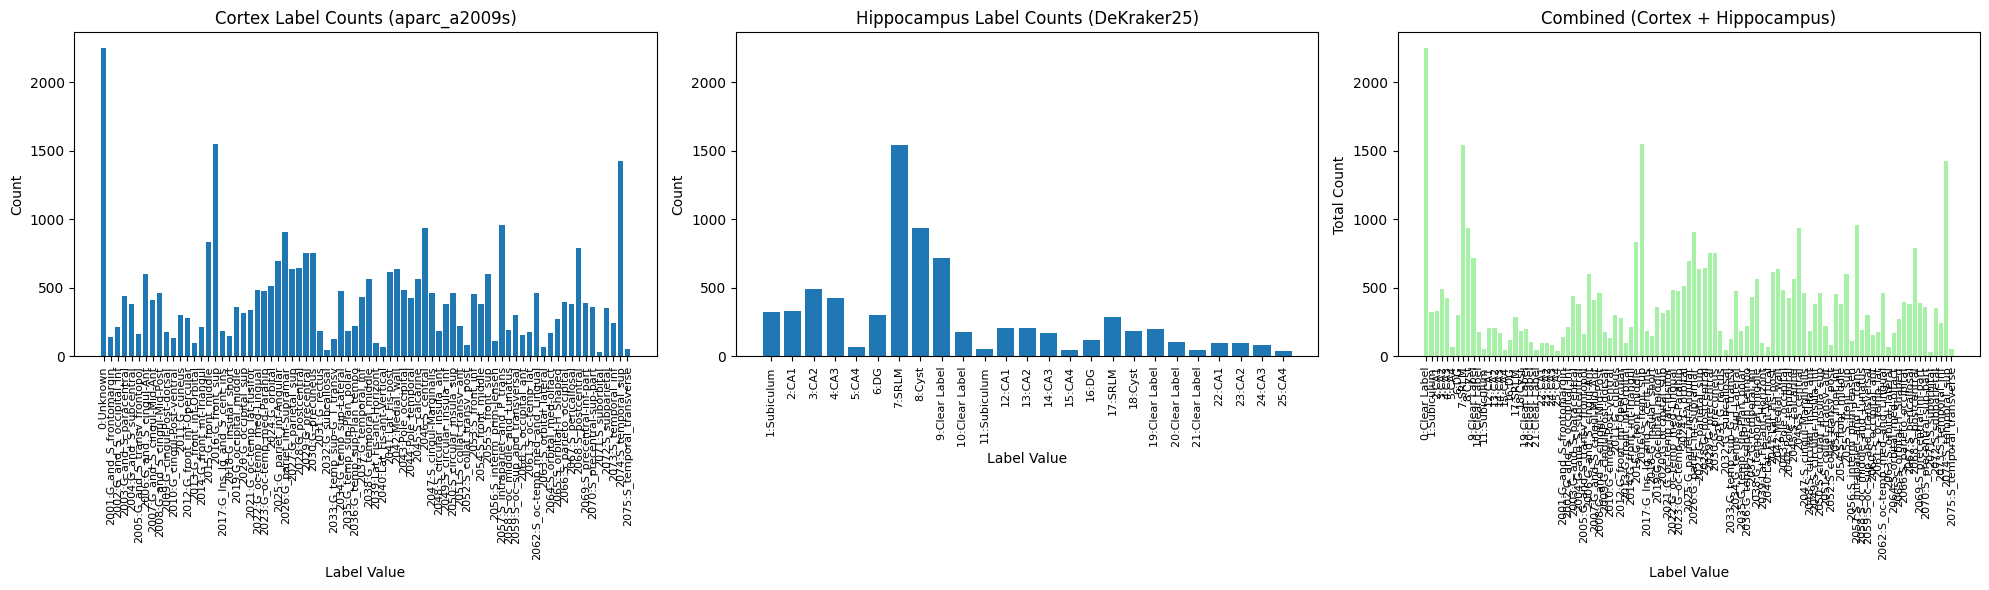

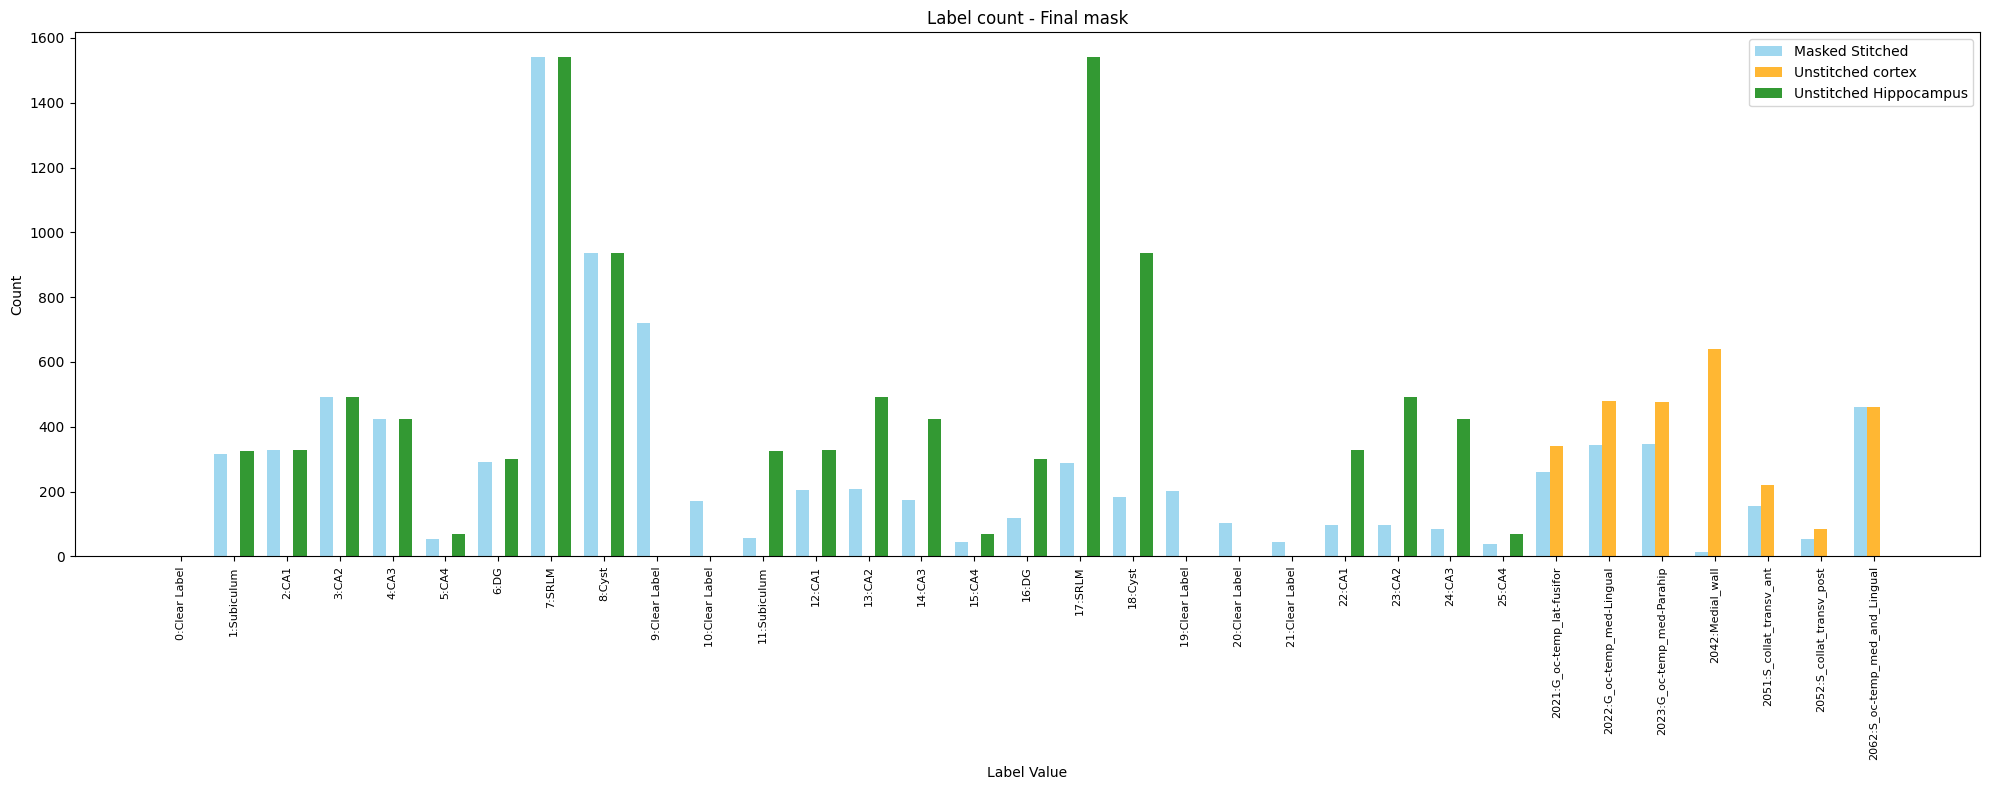

In [15]:
# FUNCTION CALLS
importlib.reload(prjUtils)
_ = pv.close_all()

# 1. STITCH LABELS
print(f"\n{'='*40}\n1. STITCH LABELS...")
importlib.reload(stitch)
lblStitch_outpth, lut_outpath = stitch.stitchLabels(ctx_lbl=clean_params['ctx_lbl'], 
                                                    hipp_lbl=clean_params['hipp_lbl'], 
                                                    outPth=clean_params['tmplt_path_root'], verbose=False)
#graphStitchedLbls(lblStitch_outpth, lut_outpath)

# 2. MAKE RAW VERTEX MASK (VIA LABEL VALUES)
print(f"\n{'='*40}\n2. MAKE VERTEX MASK...")
importlib.reload(prjUtils)
raw_mask_gii, raw_mask_pth = prjUtils.make_mask(lbl_pth=lblStitch_outpth, lut_pth=lut_outpath, 
                   label_col=['mesialTemporalMask'], label_vals=[[1]], 
                   savePath=clean_params['tmplt_path_root'],
                   saveName=f"mask-mTemp_stitch_ctx-{clean_params['ctx_lbl']['parcName']}_hipp-{clean_params['hipp_lbl']['parcName']}_{clean_params['date']}")
raw_mask = {
    'pth': raw_mask_pth,
    'data': raw_mask_gii.darrays[0].data
}

# 3. CLEAN MASK: remove ropes, fill holes, erode + dilate
print(f"\n{'='*40}\n3. CLEAN VERTEX MASK...")
mask_clean_save_pth = clean_mask(raw_mask, clean_params, example_participant)
print(f"\n{'-'*40}\nFINAL MASK SAVED TO: {mask_clean_save_pth}")

# 4. MASK LABEL FILE
print(f"\n{'='*40}\n4. MASK THE LABEL FILE...")
print(f"Retrieving label data from original mask")
lbl_stitch_masked_raw_pth = prjUtils.apply_mask_to_stitched_labelsGii(pth_inputLbl_gii=lblStitch_outpth,
                  pth_mask_gii=raw_mask_pth,
                  pth_out=os.path.join(clean_params['tmplt_path_root'], f"labels_stitch_ctx-{clean_params['ctx_lbl']['parcName']}_hipp-{clean_params['hipp_lbl']['parcName']}_{clean_params['date']}_mask-mTemp.label.gii"),)
print(f"Retrieving label data from cleaned mask")
lbl_stitch_masked_clean_pth = prjUtils.apply_mask_to_stitched_labelsGii(pth_inputLbl_gii=lblStitch_outpth,
                  pth_mask_gii=mask_clean_save_pth,
                  pth_out=os.path.join(clean_params['tmplt_path_root'], f"labels_stitch_ctx-{clean_params['ctx_lbl']['parcName']}_hipp-{clean_params['hipp_lbl']['parcName']}_{clean_params['date']}_mask-mTempClean.label.gii"),)


# 5. VISUALIZE LABELS
graphCtxHippLbls(clean_params['ctx_lbl'], clean_params['hipp_lbl'], label_colName=clean_params['ctx_lbl']['lut_idx_label_colNames'][1])
#graphStitchMaskLbls(lbl_stitch_mask_pth=lbl_stitch_masked_raw_pth, details_csv_pth=lut_outpath, ctx_lbl=clean_params['ctx_lbl'], hipp_lbl=clean_params['hipp_lbl'], label_colName=clean_params['ctx_lbl']['lut_idx_label_colNames'][1], title = 'Label count - Raw mask')
graphStitchMaskLbls(lbl_stitch_mask_pth=lbl_stitch_masked_clean_pth, details_csv_pth=lut_outpath, ctx_lbl=clean_params['ctx_lbl'], hipp_lbl=clean_params['hipp_lbl'], label_colName=clean_params['ctx_lbl']['lut_idx_label_colNames'][1],
                    title = 'Label count - Final mask')   


In [ ]:
# apply to other examples to visualize
demographics
study

In [ ]:

surf_mask_pth = '/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-PNC018_ses-a1/surfs/sub-PNC018_ses-a1_hemi-L_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_12Feb2026-1304_mask-mTempClean-ctx-Destrieux_hipp-DK25_03Mar2026.surf.gii'

# identify sulci via curvature
surf_final = nib.load(surf_mask_pth)
vrtx_final = surf_final.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
faces_final = surf_final.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data

PD1, PD2, PV1, PV2, bad_vertices = igl.principal_curvature(vrtx_final, faces_final)
h = (PV1 + PV2)/2 # mean curvature by vertex


In [7]:
def rotate_gradient_tangent(vertices, faces, grad_H_3D):
    """Project gradient to tangent plane + rotate 90° for equicurvature."""
    n_vertices = len(vertices)
    equi_dir = np.zeros((n_vertices, 3))
    
    for v in range(n_vertices):
        # 1. Surface normal at v (average adjacent face normals)
        normal = compute_vertex_normal(vertices, faces, v)
        normal /= np.linalg.norm(normal)
        
        # 2. Project gradient to tangent plane
        grad_tangent = grad_H_3D[v] - np.dot(grad_H_3D[v], normal) * normal
        
        if np.linalg.norm(grad_tangent) < 1e-8:
            continue  # Flat region
            
        grad_tangent /= np.linalg.norm(grad_tangent)
        
        # 3. Rotate 90° in tangent plane: cross product with normal
        equi_dir[v] = np.cross(normal, grad_tangent)  # ⊥ grad_tangent, in tangent plane
        
        # Normalize
        equi_dir[v] /= np.linalg.norm(equi_dir[v])
    
    return equi_dir

def equicurvature_streamlines(vertices, faces, H, seeds=None, max_length=1000):
    """
    Trace equicurvature lines from seeds or high-curvature points.
    
    Args:
        H: Mean curvature per vertex
        seeds: Starting vertices (or auto-detect)
    """
    adj_list = build_adj_list(faces)
    
    # 1. COMPUTE DISCRETE GRADIENT FIELD
    grad_H = compute_curvature_gradient(vertices, faces, H, adj_list)
    
    # 2. ROTATE 90° FOR EQUICURVATURE DIRECTION (in tangent plane)
    equi_dir = rotate_gradient_tangent(vertices, faces, grad_H)
    
    # 3. AUTO-SEED high curvature regions (sulcal fundi/gyral crowns)
    if seeds is None:
        seeds = np.where((H < np.percentile(H, 10)) | 
                        (H > np.percentile(H, 90)))[0][:20]  # Top/bottom 10%
    
    streamlines = []
    
    for seed in seeds:
        streamline = trace_streamline(seed, equi_dir, adj_list, max_length)
        streamlines.append(streamline)
    
    return streamlines

def compute_curvature_gradient(vertices, faces, H, adj_list):
    """Compute 3D curvature gradient field."""
    n_vertices = len(vertices)
    grad_H = np.zeros((n_vertices, 3))
    
    for v in range(n_vertices):
        # Get surface normal at v
        normal_v = compute_vertex_normal(vertices, faces, v)
        grad_sum = np.zeros(3)
        weight_sum = 0
        
        for u in adj_list[v]:
            edge_vec = vertices[u] - vertices[v]
            tangent_edge = project_to_tangent(edge_vec, normal_v)
            diff = H[u] - H[v]
            
            grad_sum += diff * tangent_edge
            weight_sum += np.linalg.norm(tangent_edge)  # Edge length weighting
        
        if weight_sum > 0:
            grad_H[v] = grad_sum / weight_sum
    
    return grad_H

def project_to_tangent(edge_vec: np.ndarray, normal: np.ndarray) -> np.ndarray:
    """Project 3D edge vector onto tangent plane."""
    normal = normal / np.linalg.norm(normal)
    proj_scalar = np.dot(edge_vec, normal)
    return edge_vec - proj_scalar * normal  # Remove normal component

def rotate_gradient_tangent(vertices, faces, grad_H):
    """Rotate gradient 90° in tangent plane → equicurvature direction."""
    n_vertices = len(vertices)
    equi_dir = np.zeros((n_vertices, 3))
    
    for v in range(n_vertices):
        normal = compute_vertex_normal(vertices, faces, v)
        normal /= np.linalg.norm(normal)
        
        grad_tangent = project_to_tangent(grad_H[v], normal)
        grad_mag = np.linalg.norm(grad_tangent)
        
        if grad_mag < 1e-8:  # Flat region
            continue
            
        grad_unit = grad_tangent / grad_mag
        
        # Rotate 90°: cross(normal, gradient) = tangent vector ⊥ gradient
        equi_dir[v] = np.cross(normal, grad_unit)
        equi_dir[v] /= np.linalg.norm(equi_dir[v])
    
    return equi_dir

def trace_streamline(seed, equi_dir, adj_list, max_length=1000):
    """Follow equicurvature flow field (3D vectors)."""
    path = [seed]
    current = seed
    
    for step in range(max_length):
        if len(adj_list[current]) == 0:
            break
            
        # Project equi_dir onto neighbor edges, pick best match
        best_u = None
        best_score = -np.inf
        
        for u in adj_list[current]:
            edge_vec = equi_dir[u]
            score = np.dot(equi_dir[current], edge_vec)
            
            if score > best_score:
                best_score = score
                best_u = u
        
        if best_u is None or best_u in path[-10:]:
            break
            
        path.append(best_u)
        current = best_u
    
    return np.array(path)

def compute_vertex_normal(vertices, faces, v_idx):
    """Average adjacent face normals."""
    adj_faces = [f for f in faces if v_idx in f]
    normals = []
    
    for face in adj_faces:
        v0, v1, v2 = vertices[face]
        edge1 = v1 - v0
        edge2 = v2 - v0
        face_normal = np.cross(edge1, edge2)
        normals.append(face_normal)
    
    if normals:
        normal = np.sum(normals, axis=0)
        return normal / np.linalg.norm(normal)
    return np.array([0, 0, 1])  # Default

def compute_curvature_gradient_approx(vertices, faces, H, adj_list):
    """Fast approximation: finite differences without projection."""
    n_vertices = len(vertices)
    grad_H = np.zeros((n_vertices, 3))
    
    # Use raw 3D differences (good enough for most cases)
    for v in range(n_vertices):
        grad_sum = np.zeros(3)
        count = 0
        
        for u in adj_list[v]:
            edge_vec = vertices[u] - vertices[v]
            edge_len = np.linalg.norm(edge_vec)
            if edge_len > 1e-8:
                grad_sum += (H[u] - H[v]) * (edge_vec / edge_len)
                count += 1
        
        if count > 0:
            grad_H[v] = grad_sum / count
    
    return grad_H


In [33]:
adj_list = build_adj_list(faces_final)
grad_H = compute_curvature_gradient_approx(vrtx_final, faces_final, h, adj_list)

_ = show_mesh_map(vrtx_final, faces_final, PV1, title= "Curvature Principal value 1 (k1)")
_ = show_mesh_map(vrtx_final, faces_final, PV2, title= "Curvature Principal value 2 (k2)")
_ = show_mesh_map(vrtx_final, faces_final, h, title= "Mean curvature")
_ = show_mesh_map(vrtx_final, faces_final, grad_H, title= "Curvature gradient")

Widget(value='<iframe src="http://localhost:43653/index.html?ui=P_0x7f1c007ce550_2&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43653/index.html?ui=P_0x7f1bfc971150_3&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43653/index.html?ui=P_0x7f1c00560b10_4&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43653/index.html?ui=P_0x7f1bc56801d0_5&reconnect=auto" class="pyvi…

In [ ]:
# Save png with annotated parcels
importlib.reload(vis)

lbl_csv = {
    'pth': lut_outpath,
    'colName_lblIdx': "idx",
    'colName_lblName': "SName",
    'colourCols': True
}

print(f"Surface path: {masked_pth}")
print(f"Label path: {lbl_stitch_masked_pth}")
out_pth = vis.vis_lbls_on_surf(surf_pth=masked_pth, 
                               lbl_pth=lbl_stitch_masked_pth, 
                               lbl_csvInfo=lbl_csv, 
                               out_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/lblVis/")